[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/semihyumusak/dasc523-labs/blob/main/Lab_02_Threads.ipynb)

*DASC 523 · Big Data Systems — open your own copy: `File → Save a copy in Drive`.*


# Lab 2 — Threads
### DASC 523 · Big Data Systems

In this lab you will measure the difference between sequential and multi-threaded execution
in Python, learn the `threading` module (create · start · join · args), and see with your own
timings where threads help (I/O-like waits) — and where the GIL stops them from helping.

> Run the cells top to bottom. The three **Programming Tasks** are your assignment.


# Single-threaded applications

In [ ]:
from time import sleep, perf_counter

def task():
    print('Starting a task...')
    sleep(1)
    print('done')


start_time = perf_counter()

task()
task()

end_time = perf_counter()

print(f'It took {end_time- start_time: 0.2f} second(s) to complete.')

The following diagram illustrates how the program works: \\
![Python-Threading-Single-threaded-App[1].png](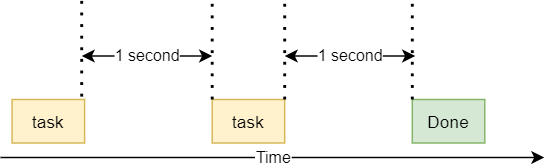)

First, the task() function executed and slept for one second. Then it executed a second time and also slept for another second. Finally, the program completes.

When the task() function called the sleep() function, the CPU didn’t do anything. This is not efficient.

This program has one process with a single thread, which is called the main thread.

Because the program has only one thread, it’s called the single-threaded program.

# Programming Task 1:
- Call the factorial function for all values from 1 to 1000

> **Two practical warnings:**
> 1. Python's default recursion limit is 1000 — `factorial(1000)` will raise `RecursionError`.
>    Raise it first: `import sys; sys.setrecursionlimit(5000)`.
> 2. `factorial()` sleeps 0.1 s per recursive call, so the FULL run takes hours. While
>    developing, shrink the sleep (e.g. 0.001) or the range — the loop structure is what matters.


In [ ]:
from time import sleep, perf_counter

def factorial(n):
    sleep(0.1)
    if n <= 1:
      return 1
    return n * factorial(n-1)



start_time = perf_counter()

#TODO Loop from 1 to 1000
factorial(100)

end_time = perf_counter()

print(f'It took {end_time- start_time: 0.2f} second(s) to complete.')

Using Python threading to develop a multi-threaded program example

To create a multi-threaded program, you need to use the Python threading module.

In [ ]:
from threading import Thread

Second, create a new thread by instantiating an instance of the Thread class:
```
# new_thread = Thread(target=fn,args=args_tuple)
```

The Thread() accepts many parameters. The main ones are:

**target:** specifies a function (fn) to run in the new thread.

**args:** specifies the arguments of the function (fn). The args argument is a tuple.

Third, start the thread by calling the start() method of the Thread instance:

```
# new_thread.start()
```

If you want to wait for the thread to complete in the main thread, you can call the join() method:
```
# new_thread.join()
```

By calling the join() method, the main thread will wait for the second thread to complete before it is terminated.

# Simple Multi-Threading




In [ ]:
from time import sleep, perf_counter
from threading import Thread


def task():
    print('Starting a task...')
    sleep(1)
    print('done')


start_time = perf_counter()

# create two new threads
t1 = Thread(target=task)
t2 = Thread(target=task)

# start the threads
t1.start()
t2.start()

# wait for the threads to complete
t1.join()
t2.join()

end_time = perf_counter()

print(f'It took {end_time- start_time: 0.2f} second(s) to complete.')

When the program executes, it’ll have three threads: the main thread is created by the Python interpreter, and two new threads are created by the program.

As shown clearly from the output, the program took one second instead of two to complete.

The following diagram shows how threads execute:


![Python-Threading-Multi-threaded-App[1].png](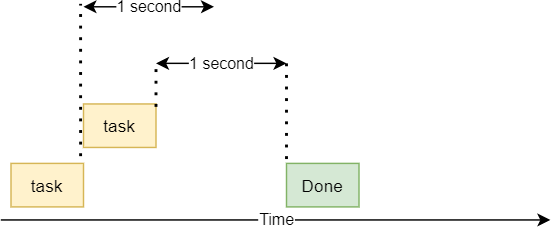)

# Passing arguments to threads

In [ ]:
from time import sleep, perf_counter
from threading import Thread


def task(id):
    print(f'Starting the task {id}...')
    sleep(1)
    print('done')


start_time = perf_counter()

# create and start 10 threads
threads = []
for n in range(1, 11):
    t = Thread(target=task, args=(n,))
    threads.append(t)
    t.start()

# wait for the threads to complete
for t in threads:
    t.join()

end_time = perf_counter()

print(f'It took {end_time- start_time: 0.2f} second(s) to complete.')

# Programming Task 2:
- Use the factorial function you created in Task 1
- Call the factorial function in 1000 threads for all values from 1000 to 2000 (Hint: in a for loop)

> Remember `sys.setrecursionlimit(5000)` (n goes up to 2000).
>
> **Question (answer in a comment):** compare the wall-clock time with Task 1's estimate.
> Why do 1000 threads finish so much faster here, and why would they NOT help if
> `factorial` did real CPU work instead of `sleep`? (Hint: the GIL — see the lecture.)


In [ ]:
from time import sleep, perf_counter
from threading import Thread


start_time = perf_counter()

# TODO Create 1000 threads to call the factorial function and put them in a list

# TODO Start all 1000 threads from the thread list

# TODO Join all 1000 threads from the thread list

end_time = perf_counter()

print(f'It took {end_time- start_time: 0.2f} second(s) to complete.')

# Programming Task 3:

Modify the following code to;
1.   Create 1000 files (add a static text to each file) to your colab environment
2. Process each file in a thread and replace the content with a specific word

In [ ]:
import os
from time import perf_counter

# --- setup: create 10 sample files so the starter below actually runs ---
os.makedirs('files', exist_ok=True)
for i in range(1, 11):
    with open(f'files/test{i}.txt', 'w') as f:
        f.write('the ids in this file will be replaced')

def replace(filename, substr, new_substr):
    print(f'Processing the file {filename}')
    with open(filename, 'r') as f:
        content = f.read()
    content = content.replace(substr, new_substr)
    with open(filename, 'w') as f:
        f.write(content)

def main():
    filenames = [f'files/test{i}.txt' for i in range(1, 11)]
    for filename in filenames:
        replace(filename, 'ids', 'id')

if __name__ == '__main__':
    start_time = perf_counter()
    main()
    end_time = perf_counter()
    print(f'It took {end_time - start_time :0.2f} second(s) to complete.')
